In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.stats import norm 
import statistics 

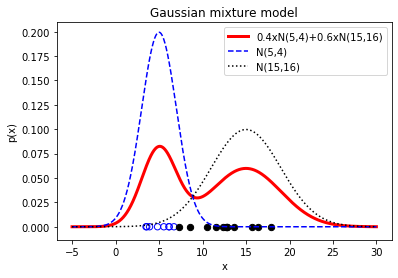

In [20]:
# Plot between -10 and 10 with .001 steps. 
x_axis = np.arange(-5, 30, 0.01) 
  
# Calculating mean and standard deviation 
#mean = statistics.mean(x_axis) 
#sd = statistics.stdev(x_axis) 
 
mean = [5, 15.]
sd = [2., 4.0]
y0 = norm.pdf(x_axis, mean[0], sd[0])
y1 = norm.pdf(x_axis, mean[1], sd[1])
y = 0.4*y0+0.6*y1
N0=8
N1=12
x0 = np.random.normal(5, 2,N0)
x1 = np.random.normal(15,4,N1)
zeros0 = np.zeros(N0)
zeros1 = np.zeros(N1)
plt.plot(x_axis, y, 'r-',label = '0.4xN(5,4)+0.6xN(15,16)', linewidth = 3)
plt.plot(x_axis,y0, 'b--', label = 'N(5,4)')
plt.plot(x_axis,y1, 'k:', label = 'N(15,16)')
 
plt.scatter(x0, zeros0, s=40, facecolors='none', edgecolors='b')
plt.scatter(x1, zeros1, s=40, facecolors='k', edgecolors='k')
plt.legend()
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Gaussian mixture model')
plt.show() 

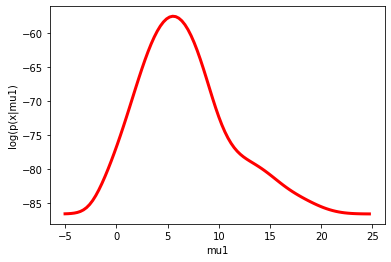

In [21]:
# for simplicity, we optimize log[p(X|theta)] over mu1, 
# assume other parameters are known

# plot the marginal log-likelihood to be maximized.
x0_x1=np.concatenate((x0,x1), axis=0)
px_theta = []
mu=[]
ELBO=[]
for i in range(100):
    u=-5+i*0.3
    px=np.sum(np.log(0.4*norm.pdf(x0_x1, u,2)+0.6*norm.pdf(x0_x1,15,4)))
    L=np.sum(0.5*np.log((0.4/0.5)*norm.pdf(x0_x1,u,2))+0.5*np.log((0.6/0.5)*norm.pdf(x0_x1,15,4)))
    px_theta.append(px)
    ELBO.append(L)
    mu.append(u)

plt.plot(mu, px_theta, 'r-',label = '0.4xN(5,4)+0.6xN(15,16)', linewidth = 3)
plt.xlabel('mu1')
plt.ylabel('log(p(x|mu1)')
plt.show()

In [22]:
px_theta[17]

-76.3684348058101

In [23]:
# compute ELBO at one point mu1_old =0 with q(z) = posterior prob
mu1_old = 0
q=np.zeros((20, 2))
# for each sample, compute q(z): q(0),q(1), posterior probability p(z|x(i),mu1_old)
q[:,0]=(0.4*norm.pdf(x0_x1,mu1_old,2))/(0.4*norm.pdf(x0_x1,mu1_old,2)+0.6*norm.pdf(x0_x1,15,4))
q[:,1]=(0.6*norm.pdf(x0_x1,15,4))/(0.4*norm.pdf(x0_x1,mu1_old,2)+0.6*norm.pdf(x0_x1,15,4))
temp = q[:,0]*np.log(0.4*norm.pdf(x0_x1, mu1_old, 2)/q[:,0])+q[:,1]*np.log(0.6*norm.pdf(x0_x1, 15, 4)/q[:,1])
ELBO = np.sum(temp)


In [24]:
ELBO

-76.79354080199433

In [25]:
# compute ELBO curve using q above for any mu1
mu_elbo=[]
ELBO_opt1=[]
for i in range(100):
    u=-5+i*0.3
    temp = q[:,0]*np.log(0.4*norm.pdf(x0_x1, u, 2)/q[:,0])+q[:,1]*np.log(0.6*norm.pdf(x0_x1, 15, 4)/q[:,1])
    temp = np.sum(temp) 
    ELBO_opt1.append(temp)
    mu_elbo.append(u)


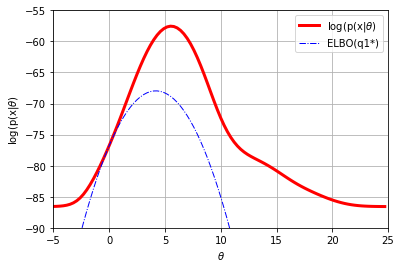

In [45]:
plt.plot(mu, px_theta, 'r-',label = r'log(p(x|$ \theta $)', linewidth = 3)
plt.plot(mu_elbo, ELBO_opt1, 'b-.',label = 'ELBO(q1*)', linewidth = 1)
plt.xlabel(r'$ \theta $')
plt.ylabel(r'log(p(x|$ \theta $)')
plt.ylim((-90,-55))
plt.xlim((-5,25))
plt.grid()
plt.legend()
plt.show()

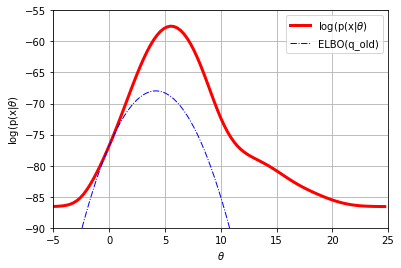

In [52]:
# compute ELBO curve using an arbitrary q(z) on each sample
#q_r=np.zeros((20, 2))
q_r[:,0]=0.2*q[:,0]
q_r[:,1]=1-q_r[:,0]
q_r[4,0]=0.11    # a random selection
q_r[4,1]=1-q[4,0]

mu_elbo=[]
ELBO=[]
for i in range(100):
    u=-5+i*0.3
    temp = q_r[:,0]*np.log(0.4*norm.pdf(x0_x1, u, 2)/q_r[:,0])+q_r[:,1]*np.log(0.6*norm.pdf(x0_x1, 15, 4)/q_r[:,1])
    temp = np.sum(temp) 
    ELBO.append(temp)
    mu_elbo.append(u)
plt.plot(mu, px_theta, 'r-',label = r'log(p(x|$ \theta $)', linewidth = 3)
#plt.plot(mu_elbo, ELBO, 'k--',label = 'ELBO(q)', linewidth = 1)
plt.plot(mu_elbo, ELBO_opt1, 'b-.',label = 'ELBO(q_old)', linewidth = 1)
plt.xlabel(r'$ \theta $')
plt.ylabel(r'log(p(x|$ \theta $)')
plt.ylim((-90,-55))
plt.xlim((-5,25))
plt.legend()
plt.grid()
plt.show()

In [53]:
# compute mu1_new by argmax(ELBO(q_old))
N=np.sum(q,axis=0)    #GMM Nk=sum over n (p(z=k|xn, mu1_old)

In [34]:
mu1_new=(1/N[0])*np.sum(x0_x1*q[:,0])  # GMM, weighted average of samples

In [35]:
q2=np.zeros((20, 2))
# for each sample, compute q(z): q(0),q(1), posterior probability p(z|x(i),mu1_old)
q2[:,0]=(0.4*norm.pdf(x0_x1,mu1_new,2))/(0.4*norm.pdf(x0_x1,mu1_new,2)+0.6*norm.pdf(x0_x1,15,4))
q2[:,1]=(0.6*norm.pdf(x0_x1,15,4))/(0.4*norm.pdf(x0_x1,mu1_new,2)+0.6*norm.pdf(x0_x1,15,4))

# compute ELBO curve using q above for any mu1
#mu_elbo=[]
ELBO_opt2=[]
for i in range(100):
    u=-5+i*0.3
    temp = q2[:,0]*np.log(0.4*norm.pdf(x0_x1, u, 2)/q2[:,0])+q2[:,1]*np.log(0.6*norm.pdf(x0_x1, 15, 4)/q2[:,1])
    temp = np.sum(temp) 
    ELBO_opt2.append(temp)
#    mu_elbo.append(u)

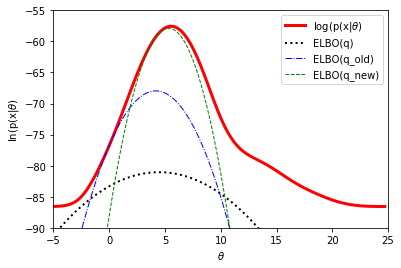

In [51]:
plt.plot(mu, px_theta, 'r-',label = r'log(p(x|$ \theta $)', linewidth = 3)
plt.plot(mu_elbo, ELBO, 'k:',label = 'ELBO(q)', linewidth = 2)
plt.plot(mu_elbo, ELBO_opt1, 'b-.',label = 'ELBO(q_old)', linewidth = 1)
plt.plot(mu_elbo, ELBO_opt2, 'g--',label = 'ELBO(q_new)', linewidth = 1)
plt.xlabel(r'$ \theta $')
plt.ylabel(r'ln(p(x|$ \theta $)')
plt.ylim((-90,-55))
plt.xlim((-5,25))
plt.legend()
#plt.grid()
plt.show()

In [42]:
print (mu1_old, mu1_new)

0 4.183945407617274
